#인공지능개론 4주차 과제

###컴퓨터공학과 202337644 김태규
---

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv'
df = pd.read_csv(path)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
# 기본 정보 확인
print("--- 데이터 기본 정보 ---")
print(df.info())

# 결측치 개수 확인
print("\n--- 결측치 확인 ---")
print(df.isnull().sum())

--- 데이터 기본 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- 결측치 확인 ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          

Age = 나이 <br>
Embarked = 탑승 항구 <br>
Fare = 요금

In [17]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Embarked는 최빈값(mode)으로 채우기
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

print("--- 결측치 처리 후 확인 ---")
print(df.isnull().sum())

--- 결측치 처리 후 확인 ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


le = LabelEncoder() -> 문자에서 숫자로 변환<br>
Sex = 성별 <br>
male - 1 <br>
female - 0

In [9]:
# 문자열 데이터 수치화
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex']) # male: 1, female: 0 (또는 반대)
df['Embarked'] = le.fit_transform(df['Embarked'])

print(df['Sex'], df['Embarked'])

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int64 0      2
1      0
2      2
3      2
4      2
      ..
886    2
887    2
888    2
889    0
890    1
Name: Embarked, Length: 891, dtype: int64


In [18]:
# 5. 불필요한 특성 제거 및 데이터 분리
# 학습에 불필요한 'Name', 'Ticket', 'Cabin', 'PassengerId' 등은 제외합니다.
X = df.drop(['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

--- 상관관계 히트맵 출력 중... ---


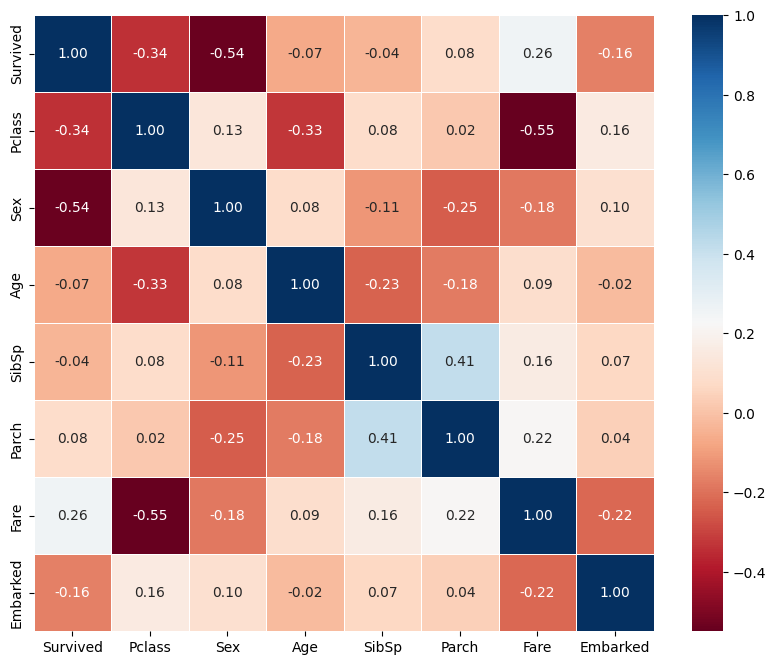

In [19]:
print("--- 상관관계 히트맵 출력 중... ---")
# 상관관계 계산에 필요한 숫자형 컬럼들만 선택
corr_data = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.show()

#
<hr>
빨강 - 양의 상관관계 (같이 증가) <br>
파랑 - 음의 상관관계 (반대로 움직임) <br>
옅은 색 - 관계 거의 없음 <br>
<hr>
성별이 생존에 큰 영향 있음<br>
여성 -> 생존률 높음 <br>
남성 -> 생존률 낮음 <br>
<hr>
객실 등급이 낮을수록(3등석) 생존률 낮음 <br>
돈 많을수록 살 확률 높음
<hr>
요금이 높을수록 생존률 높음 <br>
결국 부자 = 생존률 높음
<hr>
나이는 큰 영향 없음




In [21]:
clf_lr = LogisticRegression(random_state=0, max_iter=1000)
clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_test)

print("\n--- Logistic Regression Classifier ---")
print("정확도:", accuracy_score(y_test, pred_lr))
print("혼동 행렬:\n", confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
정확도: 0.7988826815642458
혼동 행렬:
 [[92 18]
 [18 51]]


In [22]:
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)
pred_dt = clf_dt.predict(X_test)

print("\n--- Decision Tree Classifier ---")
print("정확도:", accuracy_score(y_test, pred_dt))
print("혼동 행렬:\n", confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
정확도: 0.7877094972067039
혼동 행렬:
 [[94 16]
 [22 47]]


In [23]:
clf_rf = RandomForestClassifier(random_state=0)
clf_rf.fit(X_train, y_train)
pred_rf = clf_rf.predict(X_test)

print("\n--- Random Forest Classifier ---")
print("정확도:", accuracy_score(y_test, pred_rf))
print("혼동 행렬:\n", confusion_matrix(y_test, pred_rf))


--- Random Forest Classifier ---
정확도: 0.8547486033519553
혼동 행렬:
 [[101   9]
 [ 17  52]]
